<a href="https://colab.research.google.com/github/Raditya-Z/MachineLearning_244107020144/blob/main/QUIZ1/PerbandinganKsama-MetodeKmeans/Perbandingan_3_File_KMeans_IPYNB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perbandingan 3 File K-Means

Notebook ini membaca **langsung tiga file `.ipynb`**:
- K-Means Euclidean
- K-Means Manhattan
- K-Means Cosine

Tidak perlu upload file Excel. Nilai evaluasi dan gambar PCA diambil dari output yang sudah tersimpan di masing-masing notebook.

> Jalankan ketiga notebook utama terlebih dahulu sampai selesai dan simpan notebook beserta outputnya sebelum di-upload ke notebook ini.


## 0. Setup


In [1]:
import json
import re
import base64
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


## 1. Upload Ketiga File Notebook


In [2]:
from google.colab import files

uploaded = files.upload()

print('File yang di-upload:')
for name in uploaded:
    print('-', name)


Saving K4_Studi_Kasus_KMeans_Manhattan2.ipynb to K4_Studi_Kasus_KMeans_Manhattan2.ipynb
Saving K4_Studi_Kasus_KMeans_Euclidean2.ipynb to K4_Studi_Kasus_KMeans_Euclidean2.ipynb
Saving K4_Studi_Kasus_KMeans_Cosine2.ipynb to K4_Studi_Kasus_KMeans_Cosine2.ipynb
File yang di-upload:
- K4_Studi_Kasus_KMeans_Manhattan2.ipynb
- K4_Studi_Kasus_KMeans_Euclidean2.ipynb
- K4_Studi_Kasus_KMeans_Cosine2.ipynb


### 1.1 Menentukan File Euclidean, Manhattan, dan Cosine


In [3]:
uploaded_names = list(uploaded.keys())

def cari_file(kata):
    hasil = [
        f for f in uploaded_names
        if kata.lower() in f.lower()
    ]
    if len(hasil) == 0:
        raise FileNotFoundError(
            f'File {kata} tidak ditemukan.'
        )
    return hasil[0]

FILE_EUCLIDEAN = cari_file('euclidean')
FILE_MANHATTAN = cari_file('manhattan')
FILE_COSINE = cari_file('cosine')

print('Euclidean :', FILE_EUCLIDEAN)
print('Manhattan :', FILE_MANHATTAN)
print('Cosine    :', FILE_COSINE)


Euclidean : K4_Studi_Kasus_KMeans_Euclidean2.ipynb
Manhattan : K4_Studi_Kasus_KMeans_Manhattan2.ipynb
Cosine    : K4_Studi_Kasus_KMeans_Cosine2.ipynb


## 2. Fungsi Membaca Output Notebook


In [4]:
def load_notebook(path):
    with open(
        path,
        'r',
        encoding='utf-8'
    ) as f:
        return json.load(f)

def semua_output_text(nb):
    hasil = []

    for cell in nb['cells']:
        for output in cell.get(
            'outputs',
            []
        ):
            if 'text' in output:
                hasil.append(
                    ''.join(
                        output['text']
                    )
                )

            data = output.get(
                'data',
                {}
            )

            if 'text/plain' in data:
                hasil.append(
                    ''.join(
                        data['text/plain']
                    )
                )

    return '\n'.join(hasil)

def ambil_angka(
    text,
    pattern,
    nama
):
    match = re.search(
        pattern,
        text,
        re.IGNORECASE
    )

    if match is None:
        raise ValueError(
            f'{nama} tidak ditemukan '
            'pada output notebook.'
        )

    return float(
        match.group(1)
    )

def ekstrak_metrik(
    path,
    metode
):
    nb = load_notebook(path)
    text = semua_output_text(nb)

    k = int(
        ambil_angka(
            text,
            r'Jumlah Cluster Optimal:\s*k\s*=\s*(\d+)',
            'Jumlah Cluster'
        )
    )

    silhouette = ambil_angka(
        text,
        r'Silhouette Score:\s*([0-9.]+)',
        'Silhouette Score'
    )

    db = ambil_angka(
        text,
        r'Davies-Bouldin Index:\s*([0-9.]+)',
        'Davies-Bouldin Index'
    )

    ch = ambil_angka(
        text,
        r'Calinski-Harabasz Index:\s*([0-9.]+)',
        'Calinski-Harabasz Index'
    )

    runtime = ambil_angka(
        text,
        r'Runtime\s*:\s*([0-9.]+)',
        'Runtime'
    )

    iterations = int(
        ambil_angka(
            text,
            r'Iterations\s*:\s*(\d+)',
            'Iterations'
        )
    )

    memory = ambil_angka(
        text,
        r'Peak Memory\s*:\s*([0-9.]+)',
        'Peak Memory'
    )

    return {
        'Metode': metode,
        'Jumlah Cluster': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': db,
        'Calinski-Harabasz Index': ch,
        'Execution Time (s)': runtime,
        'Iterations': iterations,
        'Peak Memory (MB)': memory
    }


## 3. Mengambil Hasil Ketiga Metode


In [5]:
hasil = [
    ekstrak_metrik(
        FILE_EUCLIDEAN,
        'Euclidean'
    ),
    ekstrak_metrik(
        FILE_MANHATTAN,
        'Manhattan'
    ),
    ekstrak_metrik(
        FILE_COSINE,
        'Cosine'
    )
]

comparison = pd.DataFrame(
    hasil
)

comparison


,Metode,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Execution Time (s),Iterations,Peak Memory (MB)
0,Euclidean,3,0.1116,2.4891,7523.82,1.81374,11,23.72
1,Manhattan,3,0.1003,3.3120,5951.36,0.64173,10,11.06
2,Cosine,3,0.1666,3.2553,6147.10,1.56065,29,30.25


### 3.1 Pemeriksaan Jumlah Cluster


In [6]:
if comparison[
    'Jumlah Cluster'
].nunique() == 1:

    k = int(
        comparison[
            'Jumlah Cluster'
        ].iloc[0]
    )

    print(
        f'Ketiga metode menggunakan '
        f'k = {k}.'
    )

else:
    print(
        'Jumlah cluster optimal '
        'ketiga metode berbeda:'
    )

    display(
        comparison[
            [
                'Metode',
                'Jumlah Cluster'
            ]
        ]
    )

    print(
        'Grafik tetap dapat dibandingkan, '
        'tetapi perlu dicatat bahwa setiap '
        'metode menggunakan k optimalnya '
        'masing-masing.'
    )


Ketiga metode menggunakan k = 3.


## 4. Diagram Perbandingan Kuantitatif


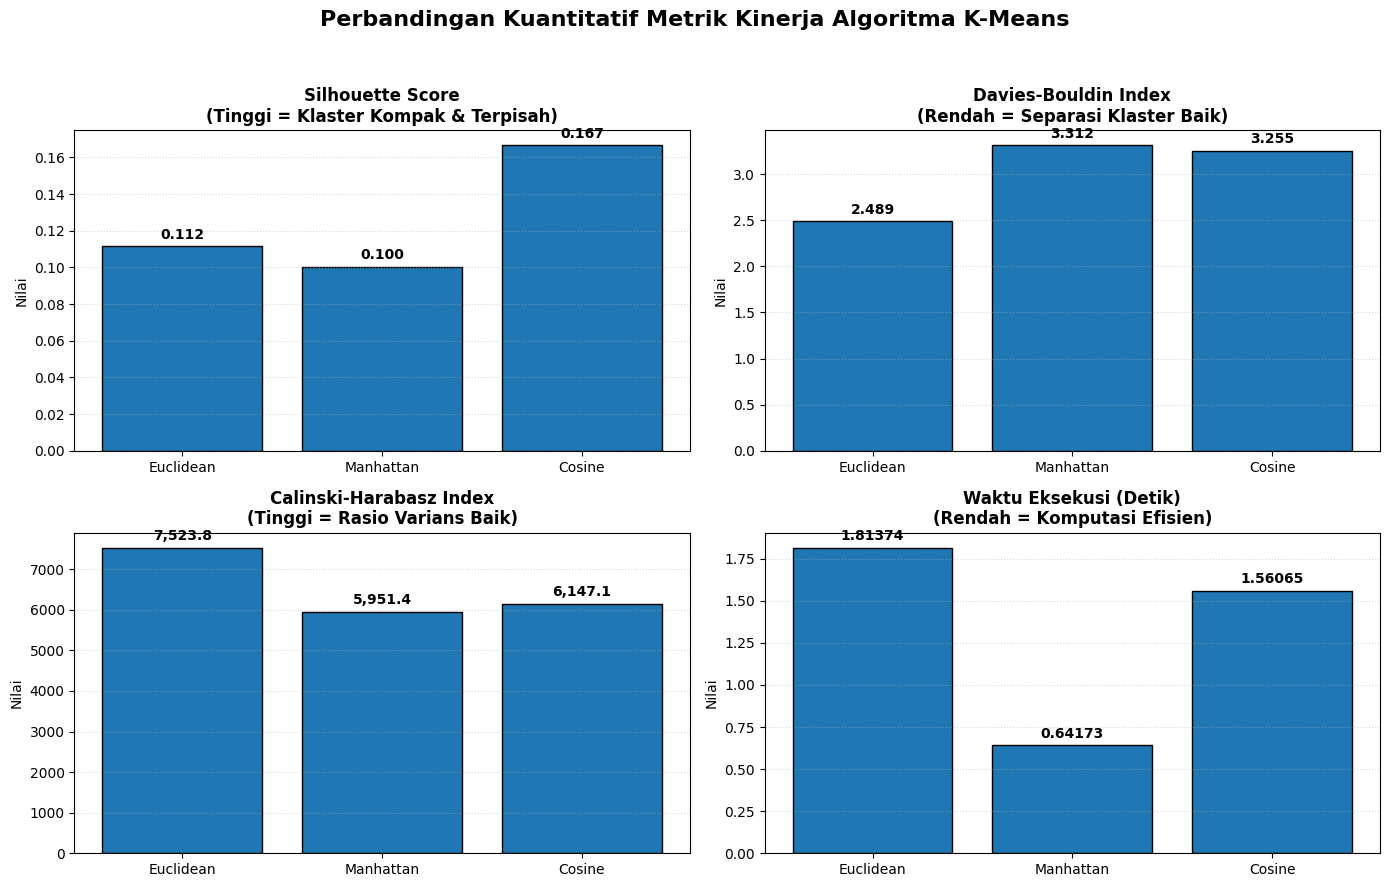

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

fig.suptitle(
    'Perbandingan Kuantitatif Metrik Kinerja Algoritma K-Means',
    fontsize=16,
    fontweight='bold'
)

items = [
    (
        'Silhouette Score',
        'Silhouette Score\n'
        '(Tinggi = Klaster Kompak & Terpisah)'
    ),
    (
        'Davies-Bouldin Index',
        'Davies-Bouldin Index\n'
        '(Rendah = Separasi Klaster Baik)'
    ),
    (
        'Calinski-Harabasz Index',
        'Calinski-Harabasz Index\n'
        '(Tinggi = Rasio Varians Baik)'
    ),
    (
        'Execution Time (s)',
        'Waktu Eksekusi (Detik)\n'
        '(Rendah = Komputasi Efisien)'
    )
]

for ax, (
    metric,
    title
) in zip(
    axes.flatten(),
    items
):
    values = comparison[
        metric
    ].astype(float)

    bars = ax.bar(
        comparison['Metode'],
        values,
        edgecolor='black'
    )

    ax.set_title(
        title,
        fontweight='bold'
    )

    ax.set_ylabel(
        'Nilai'
    )

    ax.grid(
        axis='y',
        linestyle=':',
        alpha=0.5
    )

    max_value = max(
        values.max(),
        1e-9
    )

    for bar, value in zip(
        bars,
        values
    ):
        if metric == (
            'Execution Time (s)'
        ):
            label = (
                f'{value:.5f}'
            )
        elif metric == (
            'Calinski-Harabasz Index'
        ):
            label = (
                f'{value:,.1f}'
            )
        else:
            label = (
                f'{value:.3f}'
            )

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            bar.get_height()
            + max_value*0.015,
            label,
            ha='center',
            va='bottom',
            fontweight='bold'
        )

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)

plt.savefig(
    'perbandingan_metrik_kmeans.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## 5. Mengambil Gambar PCA dari Ketiga Notebook

Notebook mencari output gambar dari cell yang berisi judul visualisasi PCA. Dengan cara ini grafik PCA yang ditampilkan adalah **hasil asli dari masing-masing notebook**, bukan dihitung ulang.


In [8]:
def ambil_gambar_pca(path):
    nb = load_notebook(path)

    for cell in nb['cells']:
        source = ''.join(
            cell.get(
                'source',
                []
            )
        )

        if (
            'PCA 2D' in source
            and 'plt.figure' in source
        ):
            for output in cell.get(
                'outputs',
                []
            ):
                data = output.get(
                    'data',
                    {}
                )

                if 'image/png' in data:
                    image_data = (
                        data['image/png']
                    )

                    if isinstance(
                        image_data,
                        list
                    ):
                        image_data = ''.join(
                            image_data
                        )

                    raw = base64.b64decode(
                        image_data
                    )

                    return Image.open(
                        io.BytesIO(raw)
                    )

    raise ValueError(
        f'Output gambar PCA tidak '
        f'ditemukan pada {path}. '
        'Pastikan notebook sudah '
        'dijalankan dan output disimpan.'
    )

img_eu = ambil_gambar_pca(
    FILE_EUCLIDEAN
)

img_ma = ambil_gambar_pca(
    FILE_MANHATTAN
)

img_co = ambil_gambar_pca(
    FILE_COSINE
)

print(
    'Ketiga gambar PCA berhasil dibaca.'
)


Ketiga gambar PCA berhasil dibaca.


## 6. Visualisasi PCA Ketiga Metode Berdampingan


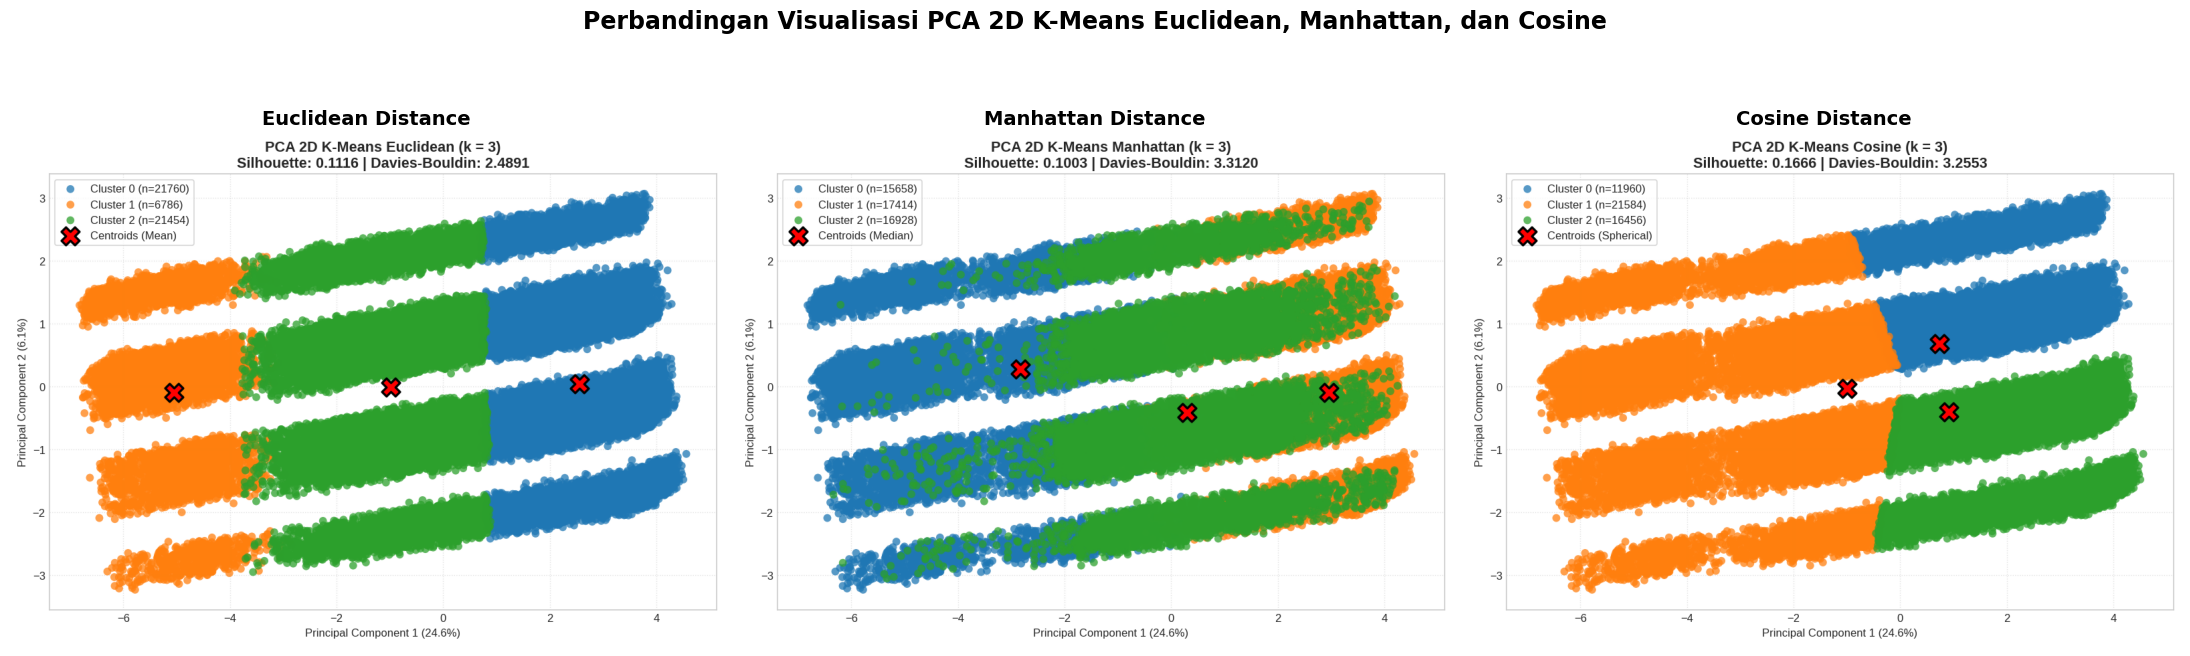

In [9]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7)
)

fig.suptitle(
    'Perbandingan Visualisasi PCA 2D '
    'K-Means Euclidean, Manhattan, dan Cosine',
    fontsize=17,
    fontweight='bold'
)

images = [
    (
        img_eu,
        'Euclidean Distance'
    ),
    (
        img_ma,
        'Manhattan Distance'
    ),
    (
        img_co,
        'Cosine Distance'
    )
]

for ax, (
    image,
    title
) in zip(
    axes,
    images
):
    ax.imshow(
        image
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.axis(
        'off'
    )

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.93
    ]
)

plt.savefig(
    'perbandingan_pca_3_metode.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## 7. Perbandingan Efisiensi Tambahan


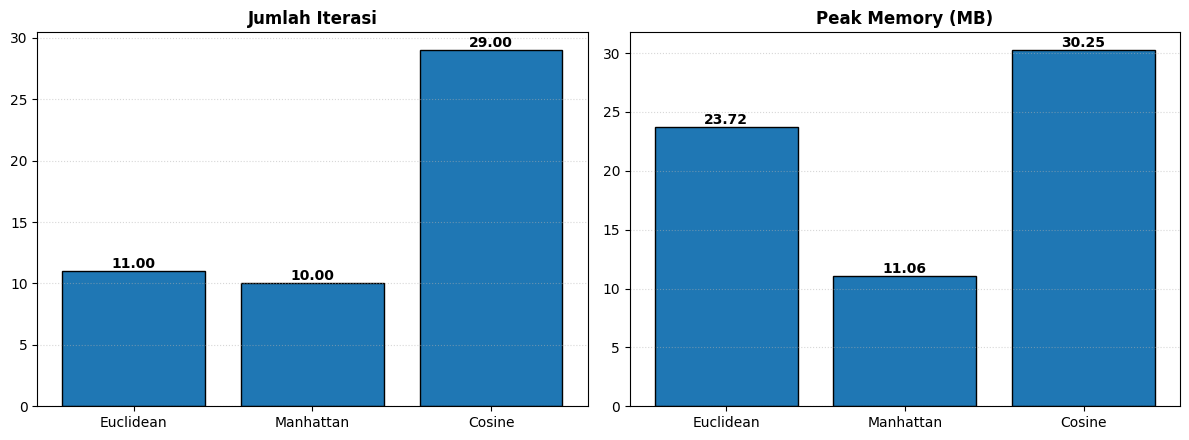

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

for ax, metric, title in [
    (
        axes[0],
        'Iterations',
        'Jumlah Iterasi'
    ),
    (
        axes[1],
        'Peak Memory (MB)',
        'Peak Memory (MB)'
    )
]:
    values = comparison[
        metric
    ]

    bars = ax.bar(
        comparison['Metode'],
        values,
        edgecolor='black'
    )

    ax.set_title(
        title,
        fontweight='bold'
    )

    ax.grid(
        axis='y',
        linestyle=':',
        alpha=0.5
    )

    for bar, value in zip(
        bars,
        values
    ):
        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            bar.get_height(),
            f'{value:.2f}',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

plt.tight_layout()
plt.show()


## 8. Tabel Hasil Akhir


In [11]:
comparison


,Metode,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Execution Time (s),Iterations,Peak Memory (MB)
0,Euclidean,3,0.1116,2.4891,7523.82,1.81374,11,23.72
1,Manhattan,3,0.1003,3.3120,5951.36,0.64173,10,11.06
2,Cosine,3,0.1666,3.2553,6147.10,1.56065,29,30.25


## 9. Export Hasil Perbandingan


In [12]:
comparison.to_excel(
    'perbandingan_3_metode_kmeans.xlsx',
    index=False
)

print(
    'Hasil berhasil disimpan:'
)

print(
    '- perbandingan_3_metode_kmeans.xlsx'
)

print(
    '- perbandingan_metrik_kmeans.png'
)

print(
    '- perbandingan_pca_3_metode.png'
)


Hasil berhasil disimpan:
- perbandingan_3_metode_kmeans.xlsx
- perbandingan_metrik_kmeans.png
- perbandingan_pca_3_metode.png


## Catatan Interpretasi

- **Silhouette Score**: semakin tinggi, pemisahan cluster semakin baik.
- **Davies-Bouldin Index**: semakin rendah, pemisahan cluster semakin baik.
- **Calinski-Harabasz Index**: semakin tinggi, struktur cluster semakin baik.
- **Execution Time**: semakin rendah, proses komputasi semakin cepat.
- Grafik PCA digunakan sebagai visualisasi hasil clustering, sedangkan evaluasi kuantitatif tetap mengacu pada metrik yang dihitung pada data asli.

Jika nilai `k` optimal dari ketiga metode berbeda, cantumkan hal tersebut saat membahas hasil karena setiap algoritma sedang dibandingkan pada konfigurasi optimalnya masing-masing.
